# Exploring with plots: Weather Data

Peter Ralph  
2026-01-13

# Weather Underground

Associated with WU is a large number of [Personal Weather
Stations](https://www.wunderground.com/pws/overview)

<figure>
<a
href="https://www.wunderground.com/wundermap?lat=44.058&amp;lon=-123.105">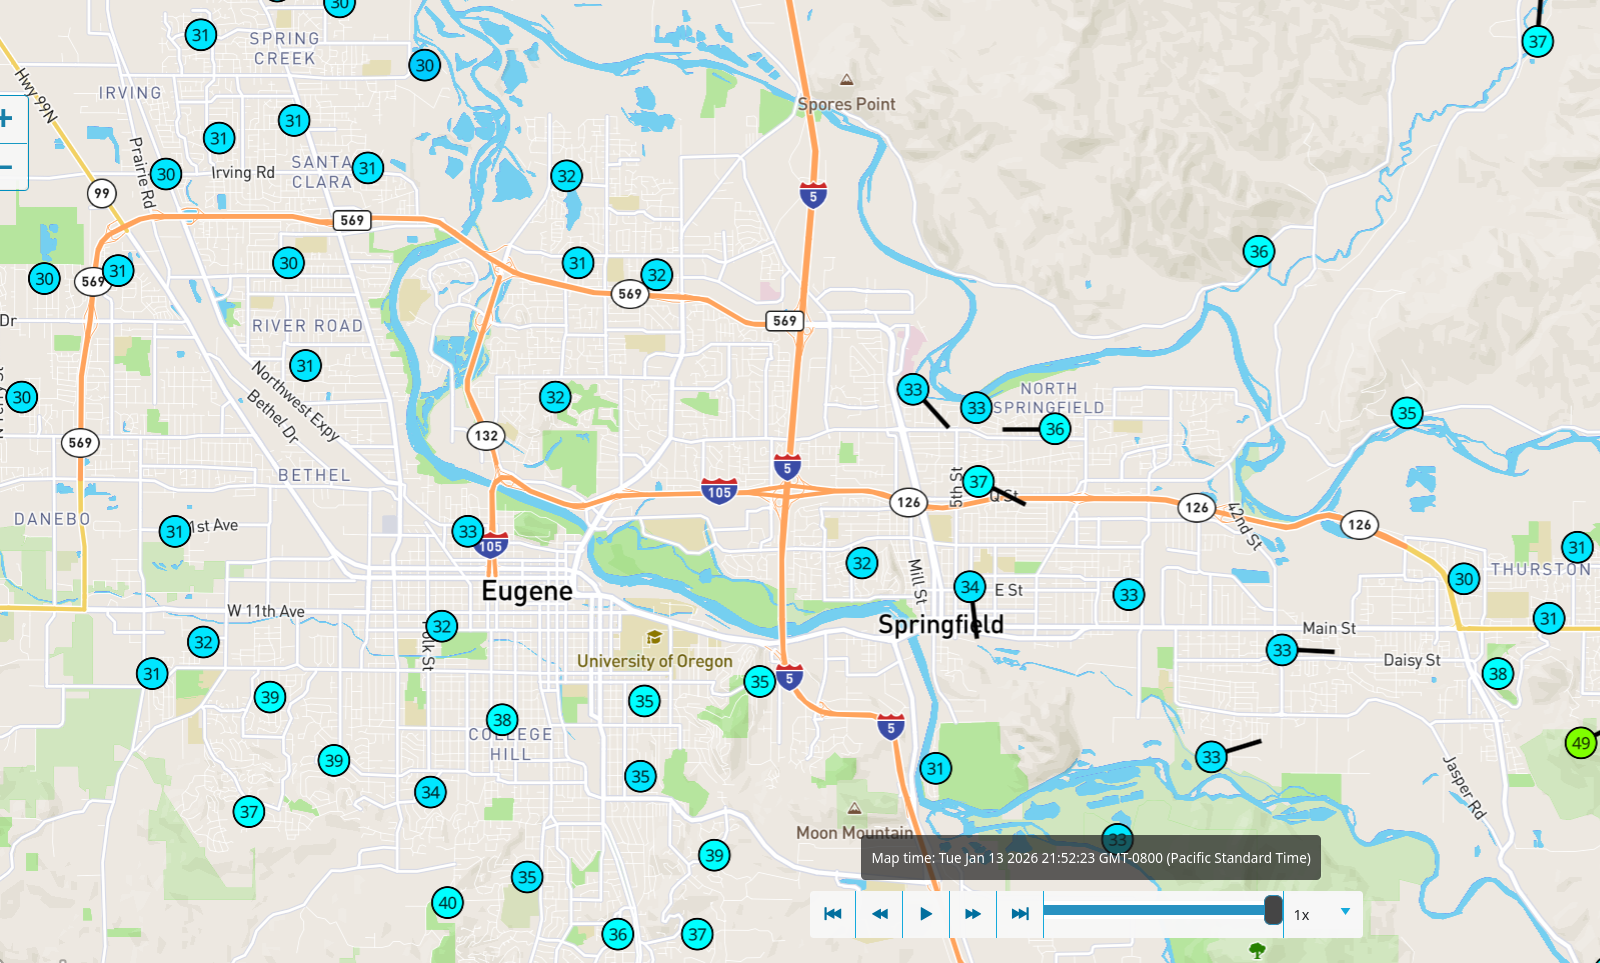</a>
<figcaption>map of weather underground stations in
Eugene/Springfield</figcaption>
</figure>

## 

From these, data is available:

<figure>
<a href="https://www.wunderground.com/dashboard/pws/KOREUGEN127">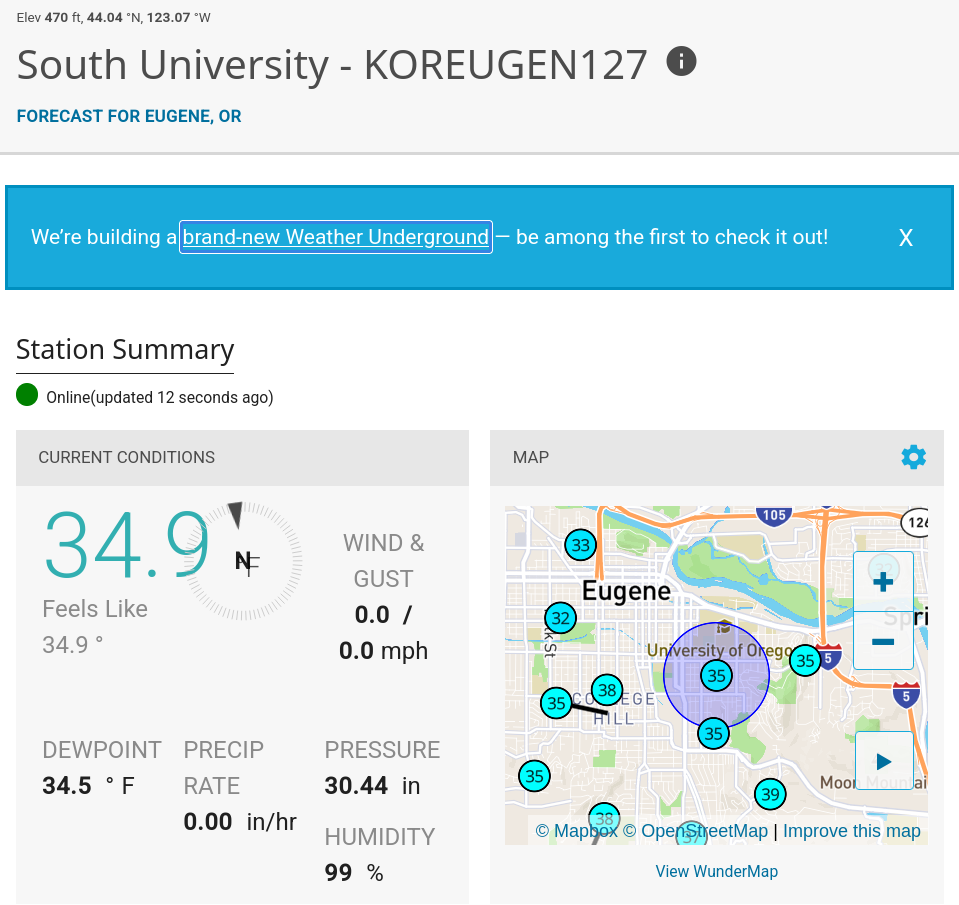</a>
<figcaption>screenshot of KOREUGEN127</figcaption>
</figure>

## 

… every five minutes:

<figure>
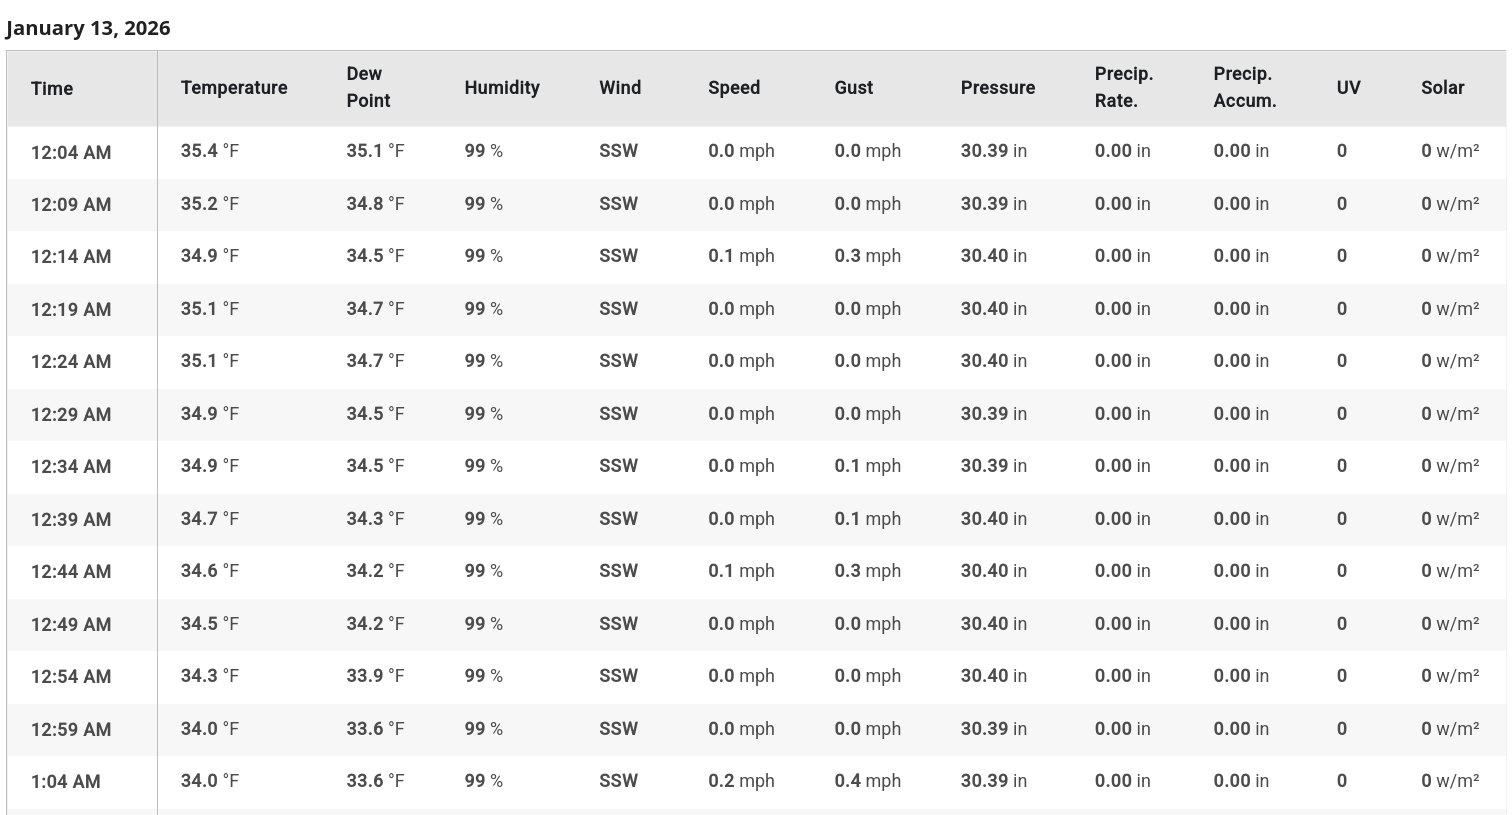
<figcaption aria-hidden="true">screenshot of data from that station in
an HTML table</figcaption>
</figure>

## Web scraping

Happily, someone has written a
[scraper](https://github.com/Karlheinzniebuhr/the-weather-scraper):

    git clone git@github.com:Karlheinzniebuhr/the-weather-scraper.git
    cd the-weather-scraper
    pip install lxml requests
    # edit stations.txt and config.py
    python weather_scraper.py

and then WAIT. (There’s 5-second timeouts between requests.)

I’ve done some for you:

-   a table of local stations: [stations.csv](data/stations.csv)
-   a zip file of data from 2025:
    [weather_2025.zip](data/weather_2025.zip)

Let’s have a look! *(unzip the file to `data/`)*

In [1]:
import pandas as pd
import plotnine as p9
import glob

stations = pd.read_csv("data/stations.csv")
stations

,name,code,lat,lon,elev
0,BETHEL,KOREUGEN31,44.080,123.200,380
1,Torrington Station,KOREUGEN67,44.120,123.150,377
2,South Eugene,KOREUGEN74,44.030,123.110,440
3,South University,KOREUGEN127,44.037,123.074,470
4,Old Baldy,KOREUGEN225,44.000,123.070,800
5,Lafferty Park,KOREUGEN226,44.020,123.100,640
6,Crescent Ave,KOREUGEN249,44.090,123.080,410
7,Alvadore,KOREUGEN260,44.100,123.270,400
8,Lema,KOREUGEN295,44.080,123.130,410
9,College Hill,KOREUGEN303,44.030,123.100,587


Better would be with a map for background, but this is okay:

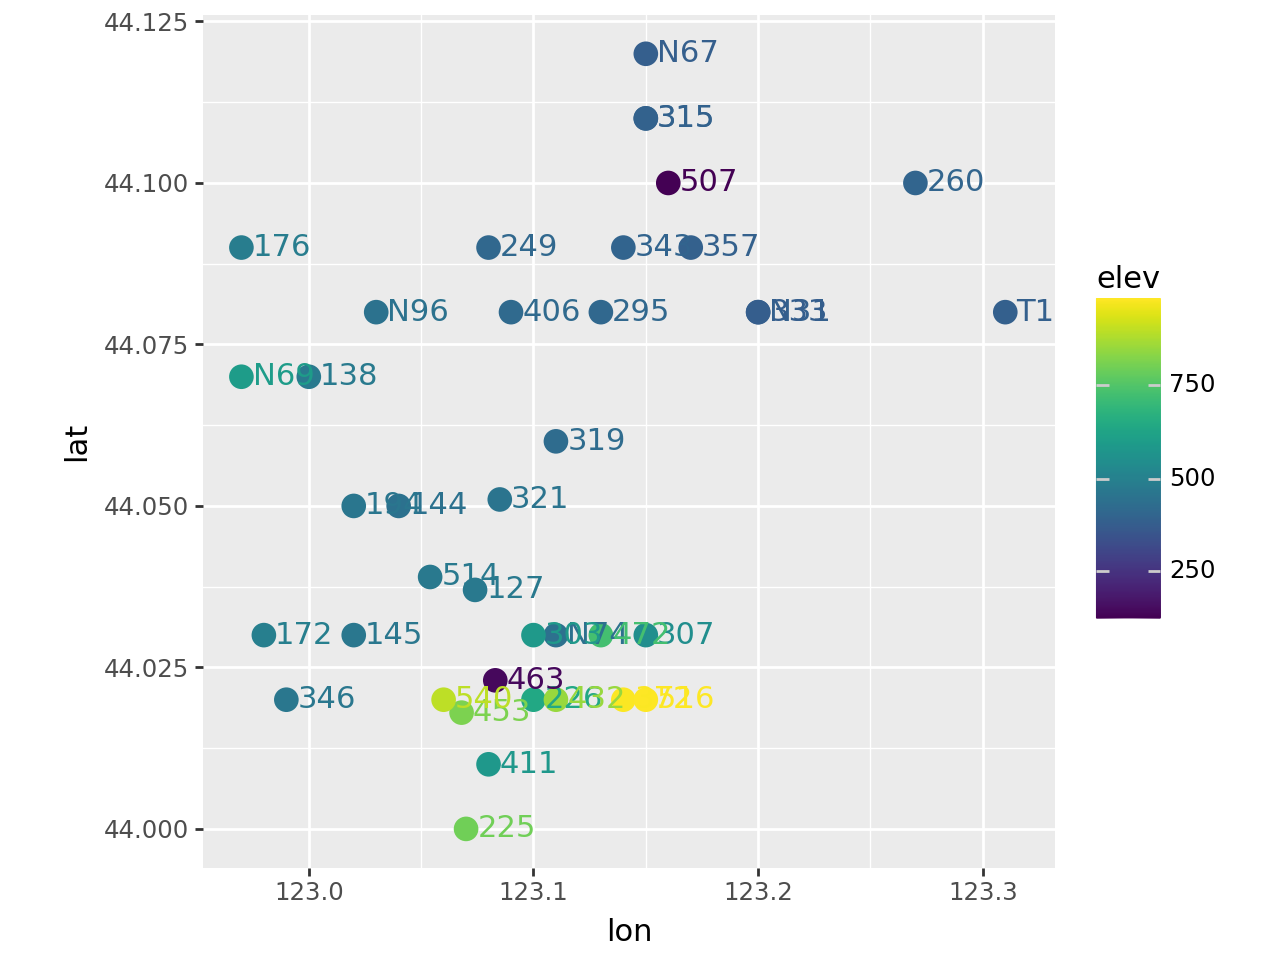

In [99]:
(
    stations
        .assign(code_num=lambda df: df['code'].str[-3:])
    >> p9.ggplot(p9.aes(x="lon", y="lat", color="elev")) 
    + p9.geom_point(size=4)
    + p9.theme(aspect_ratio=1.0)
    + p9.geom_text(p9.aes(label='code_num'), ha='left', nudge_x=0.005)
)

Each station has it’s own file, so we concatante them.
Also note the call to `pd.to_datetime()` to turn date + time into a datetime object.

In [23]:
def read_wf(f):
    x = pd.read_csv(f).convert_dtypes()
    x['code'] = f.split("/")[-1].split(".")[0]
    return x

    
wfiles = glob.glob("data/weather_2025/*.csv")

weather = pd.concat([read_wf(f) for f in wfiles])
weather['Date'] = pd.to_datetime(weather['Date'] + " " + weather['Time'], format="%Y/%m/%d %I:%M %p")
weather

,Date,Time,Temperature_C,Dew_Point_C,Humidity_%,Wind,Speed_kmh,Gust_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,UV,Solar_w/m2,code
0,2025-01-01 00:04:00,12:04 AM,5.22,4.5,95,South,2.74,3.22,1011.51,0.0,0.0,0,0.0,KOREUGEN267
1,2025-01-01 00:09:00,12:09 AM,5.17,4.67,96,South,0.16,0.32,1011.51,0.0,0.0,0,0.0,KOREUGEN267
2,2025-01-01 00:14:00,12:14 AM,5.11,4.72,97,SSE,2.09,2.74,1011.51,0.0,0.0,0,0.0,KOREUGEN267
3,2025-01-01 00:19:00,12:19 AM,5.11,4.72,97,SSE,2.41,3.7,1011.51,0.0,0.0,0,0.0,KOREUGEN267
4,2025-01-01 00:24:00,12:24 AM,5.11,4.72,97,SE,0.8,1.93,1011.51,0.0,0.0,0,0.0,KOREUGEN267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92786,2025-12-31 23:35:00,11:35 PM,2.11,1.78,98,ESE,0.16,1.45,1012.87,0.0,0.0,0,0.0,KOREUGEN321
92787,2025-12-31 23:40:00,11:40 PM,2.11,1.78,98,North,0.0,0.0,1012.87,0.0,0.0,0,0.0,KOREUGEN321
92788,2025-12-31 23:45:00,11:45 PM,2.22,1.89,98,North,0.0,0.0,1012.53,0.0,0.0,0,0.0,KOREUGEN321
92789,2025-12-31 23:50:00,11:50 PM,2.22,1.89,98,ESE,0.0,0.8,1012.53,0.0,0.0,0,0.0,KOREUGEN321


## Goals:

What we’d like to do is **understand how well rainfall in one part of
Eugene/Springfield predicts rainfall in another part**. In particular,
how well does rainfall at one point – the [National Weather Service
station](https://forecast.weather.gov/MapClick.php?lat=44.0520691&lon=-123.08675360000001)
– predict load for the municipal stormwater system?

*So:* let’s understand the data, with this goal in mind.

## Temperature:

- reasonable range of values, looks like, except for maybe one or two at -20C?
- some stations were probably not active for the whole year?

/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 49131 rows containing non-finite values.


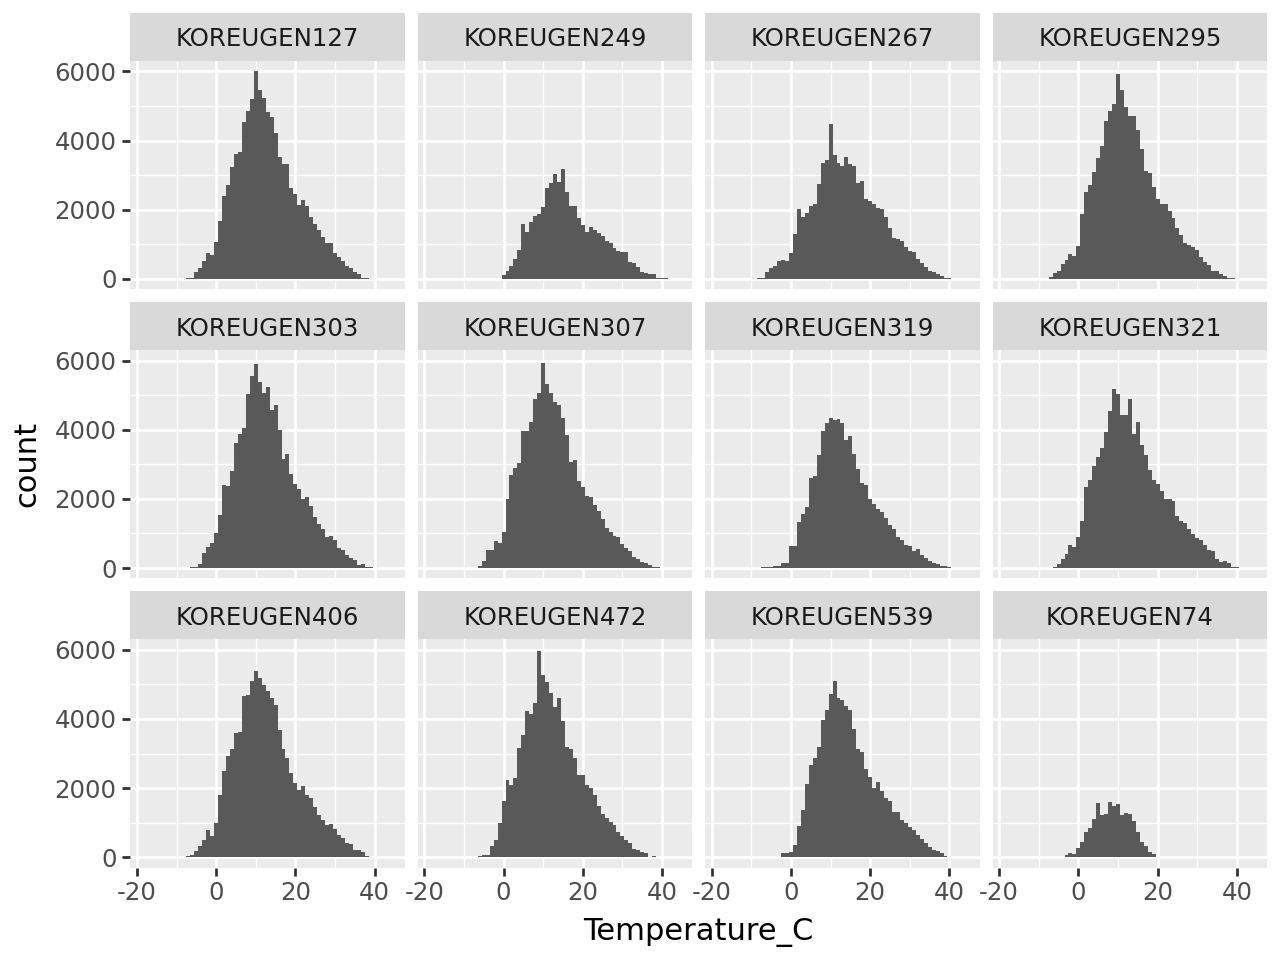

In [44]:
(
    weather
    >>
    p9.ggplot(p9.aes(x="Temperature_C"))
    + p9.geom_histogram(binwidth=1)
    + p9.facet_wrap("code")
)

The first plot of "temperature against date" is actually informative:
for instance, it shows us some clear errors (very low temperatures in the middle of summer at KOREUGEN321):

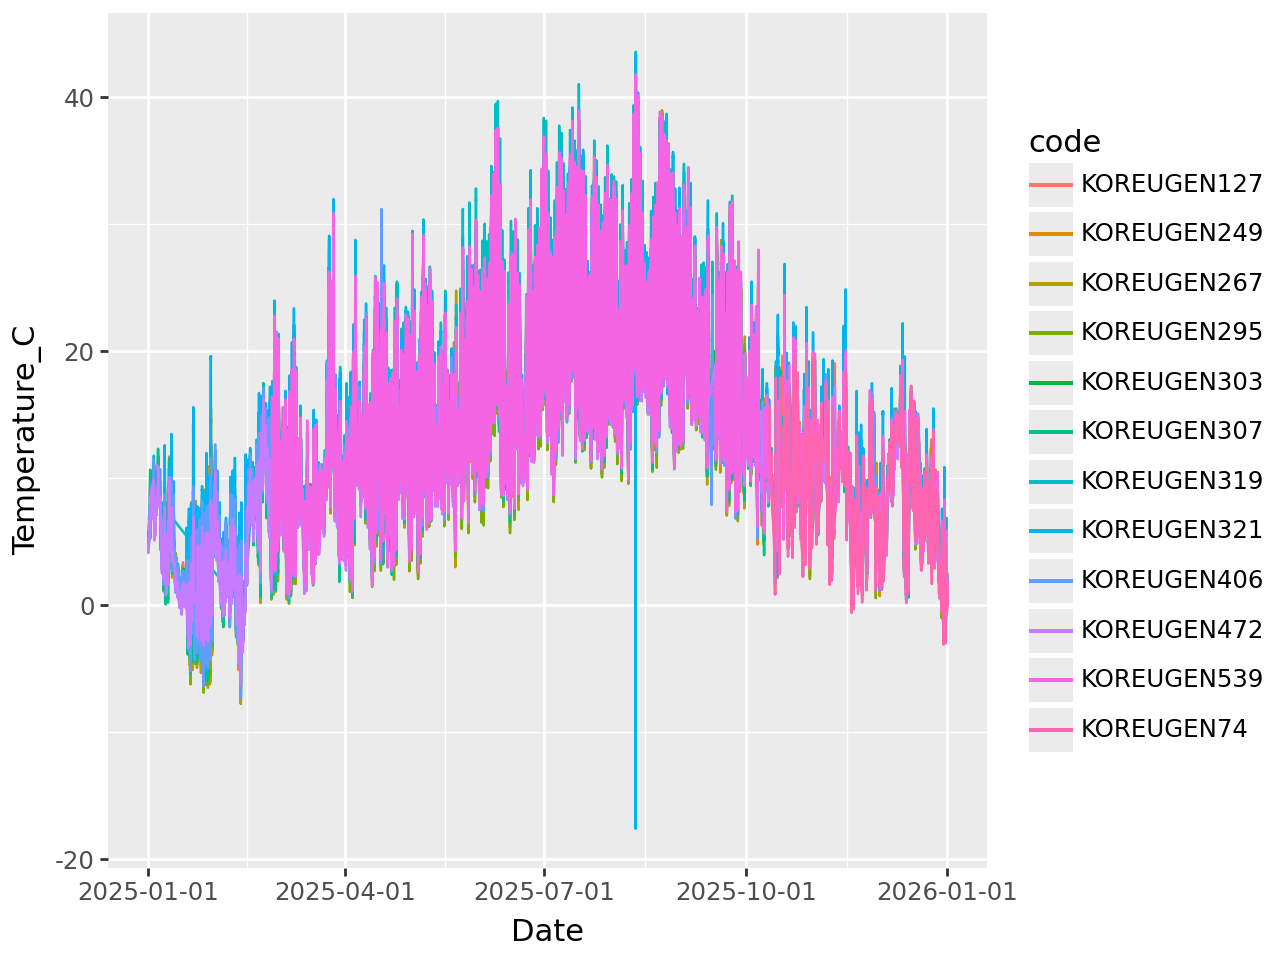

In [60]:
(
    weather
    >>
    p9.ggplot(p9.aes(x="Date", y="Temperature_C", color="code"))
    + p9.geom_line()
)

Let's make plots of temperature against time,
with one line for 'noon' and another for 'midnight'.
But first: is midnight hour 0 or hour 24? Looks like hour 0.

In [25]:
weather['Date'].dt.hour.value_counts()

Date
16    42942
15    42939
17    42922
18    42916
19    42900
22    42896
20    42893
14    42888
23    42878
21    42866
12    42857
13    42843
1     42755
11    42716
10    42670
3     42659
5     42567
6     42560
4     42552
2     42546
7     42529
9     42505
8     42500
0     42319
Name: count, dtype: int64

Okay, here's the plot; since data are logged every 5 minutes,
it should be plotting the temperature at the next observation after the noon/midnight hour.

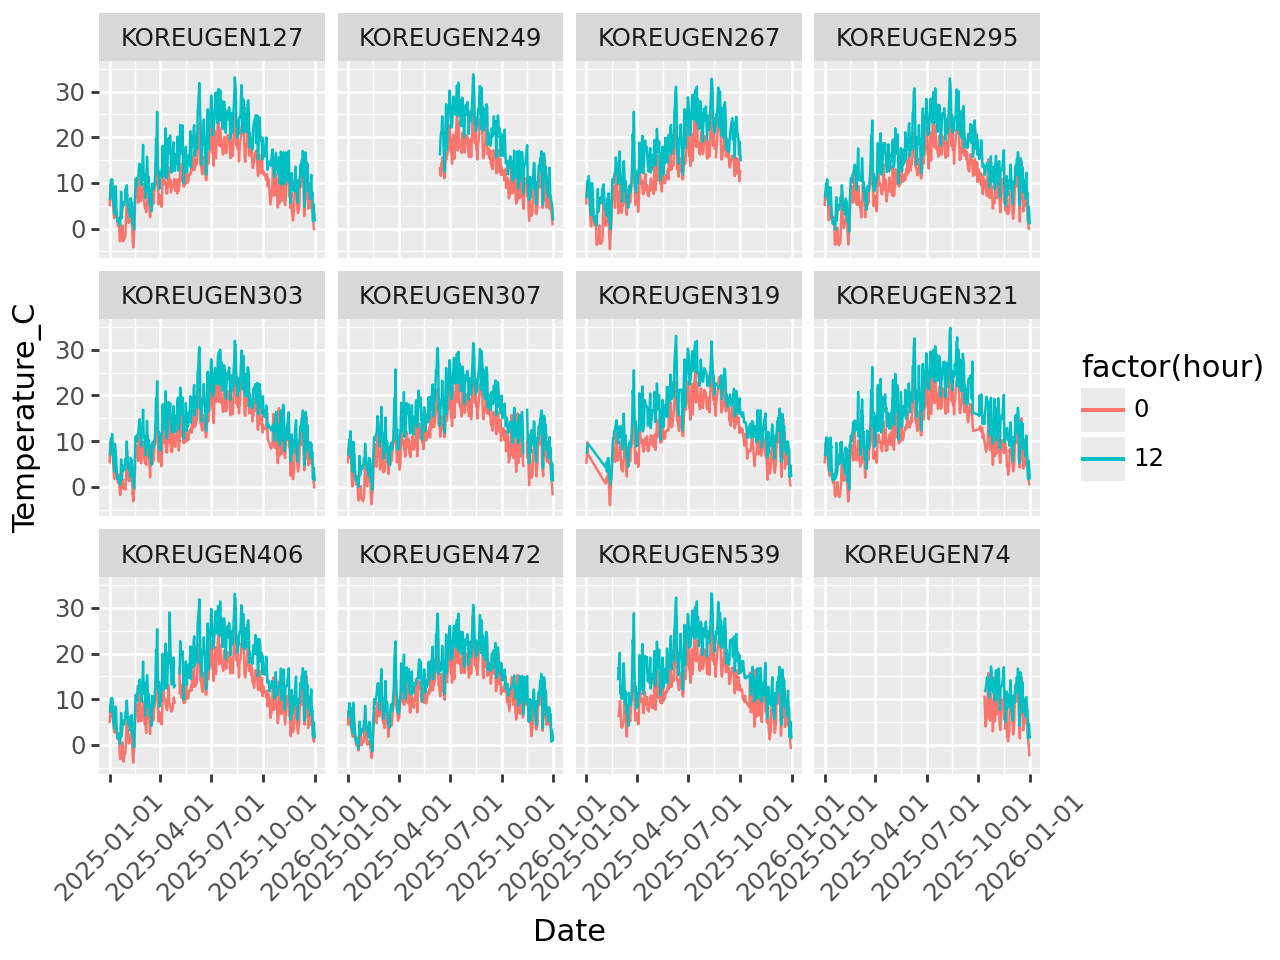

In [34]:
(
    weather
    .loc[(((weather['Date'].dt.hour == 12) | (weather['Date'].dt.hour == 0))
          & (weather['Date'].dt.minute <= 5)),:]
    .assign(hour = lambda df: df['Date'].dt.hour)
    >>
    p9.ggplot(p9.aes(x='Date', y='Temperature_C', color='factor(hour)'))
    + p9.geom_line()
    + p9.facet_wrap('code')
    + p9.theme(axis_text_x=p9.element_text(rotation=45))
)

That's a bit hard to see, let's zoom in on just one.

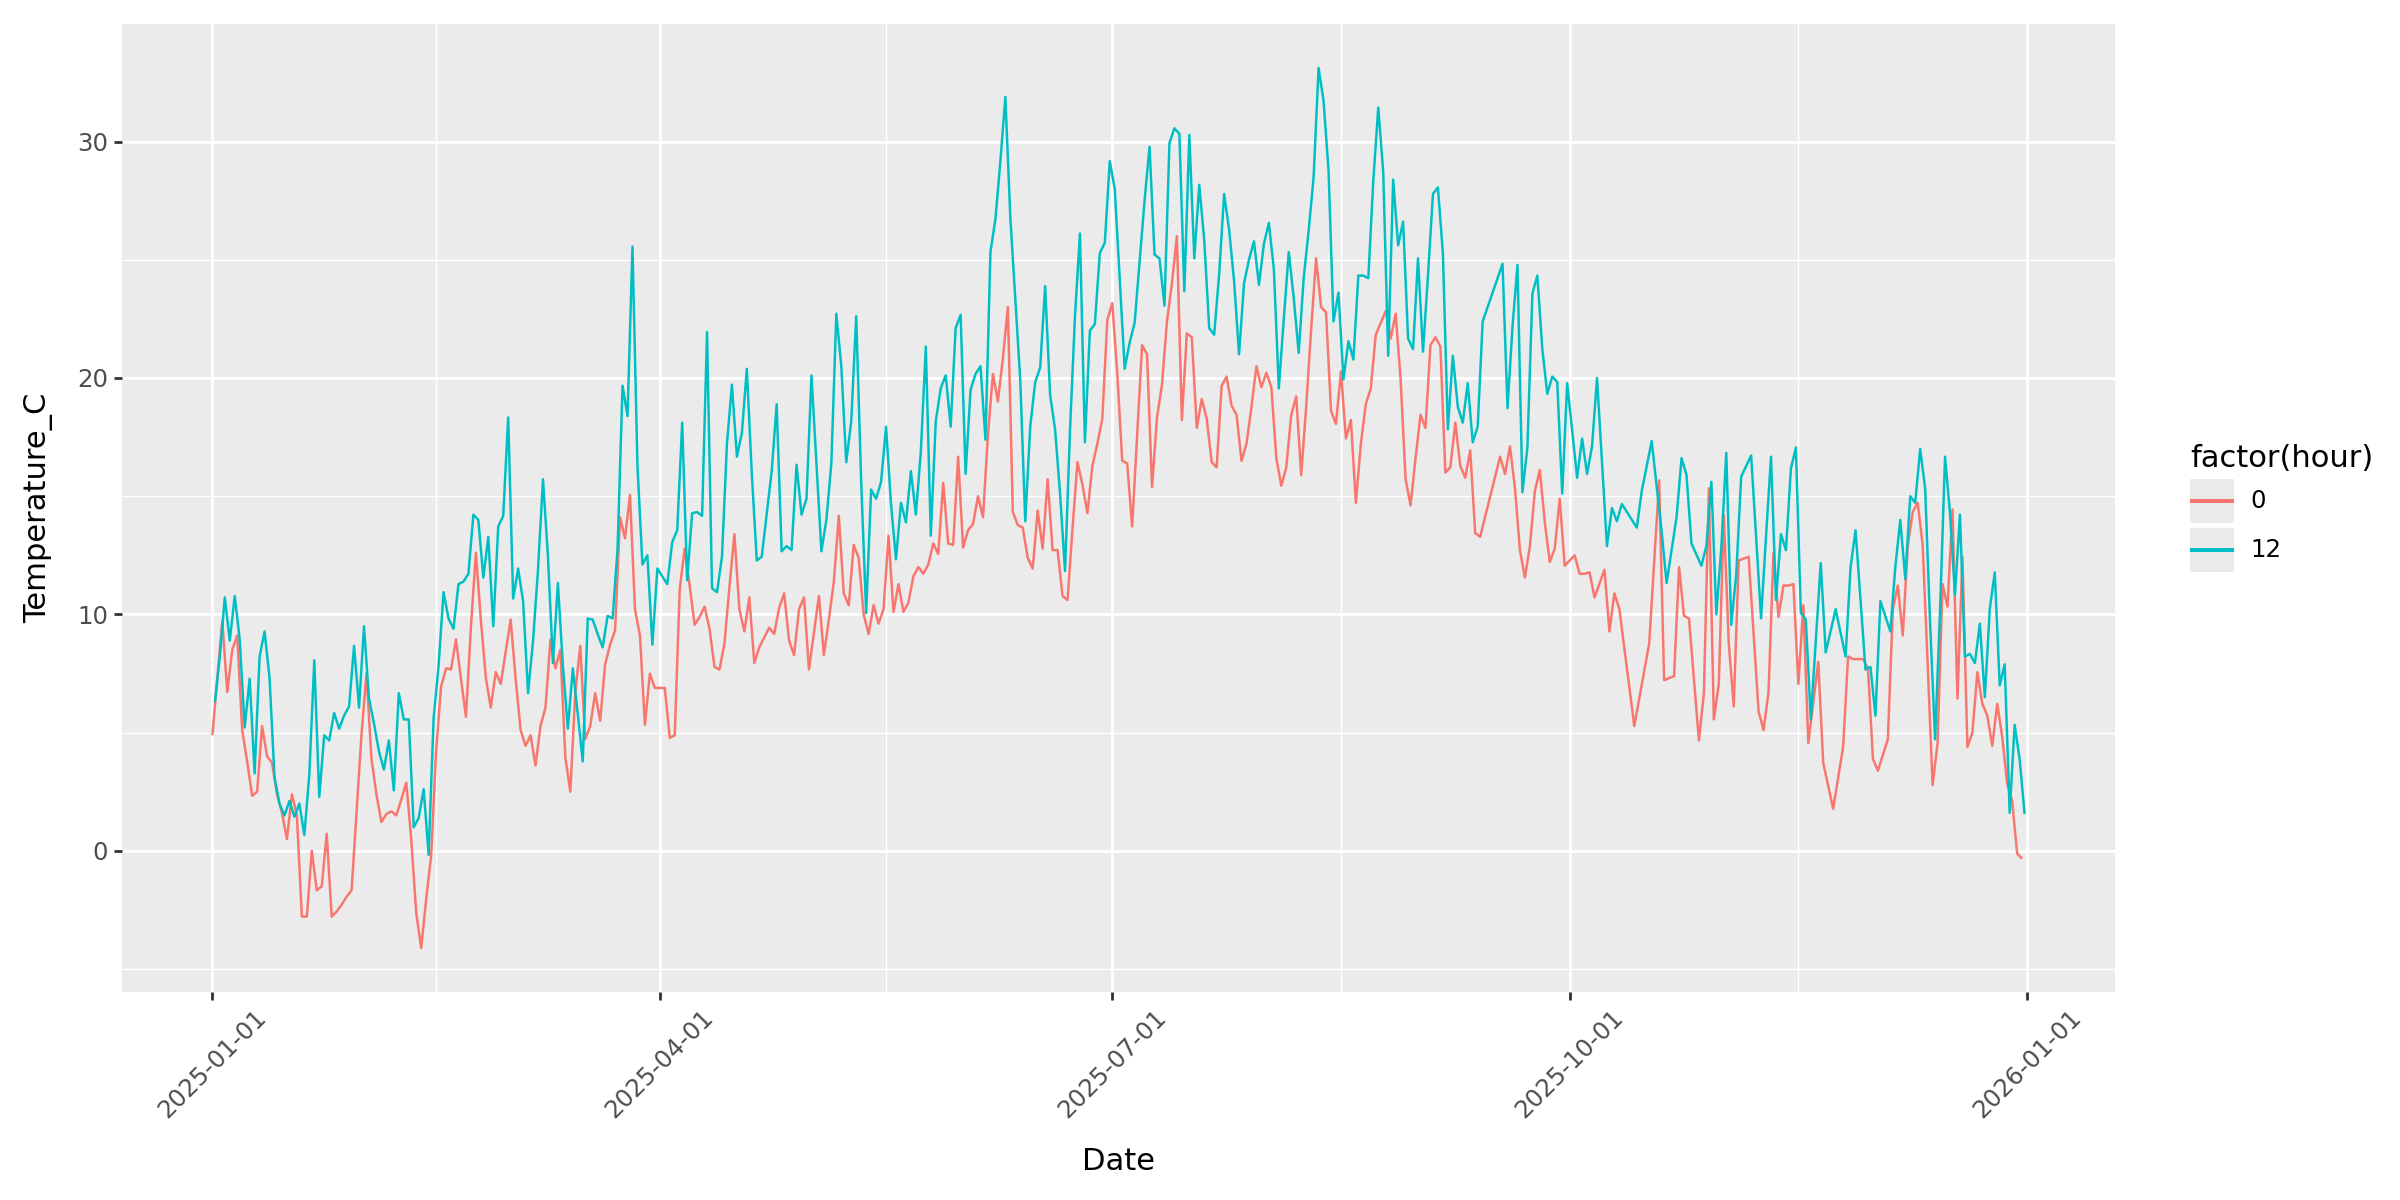

In [42]:
(
    weather
    .loc[(
          ((weather['Date'].dt.hour == 12) | (weather['Date'].dt.hour == 0))
          & (weather['Date'].dt.minute <= 5)
          & (weather['code'] == "KOREUGEN127")
         ),:]
    .assign(hour = lambda df: df['Date'].dt.hour)
    >>
    p9.ggplot(p9.aes(x='Date', y='Temperature_C', color='factor(hour)'))
    + p9.geom_line()
    + p9.theme(axis_text_x=p9.element_text(rotation=45))
    + p9.theme(figure_size=(12, 6))
)

## Precipitation rate:

- mostly zeros! histograms are very hard to see.
- a vew large values (~80): are these meaningful?

In [15]:
weather['Precip_Rate_mm'].describe()

count    977058.0
mean     0.125402
std      0.764177
min           0.0
25%           0.0
50%           0.0
75%           0.0
max         78.49
Name: Precip_Rate_mm, dtype: Float64

In [16]:
(weather['Precip_Rate_mm'] == 0).value_counts(dropna=False)

Precip_Rate_mm
True     924412
False     52646
<NA>      48560
Name: count, dtype: Int64

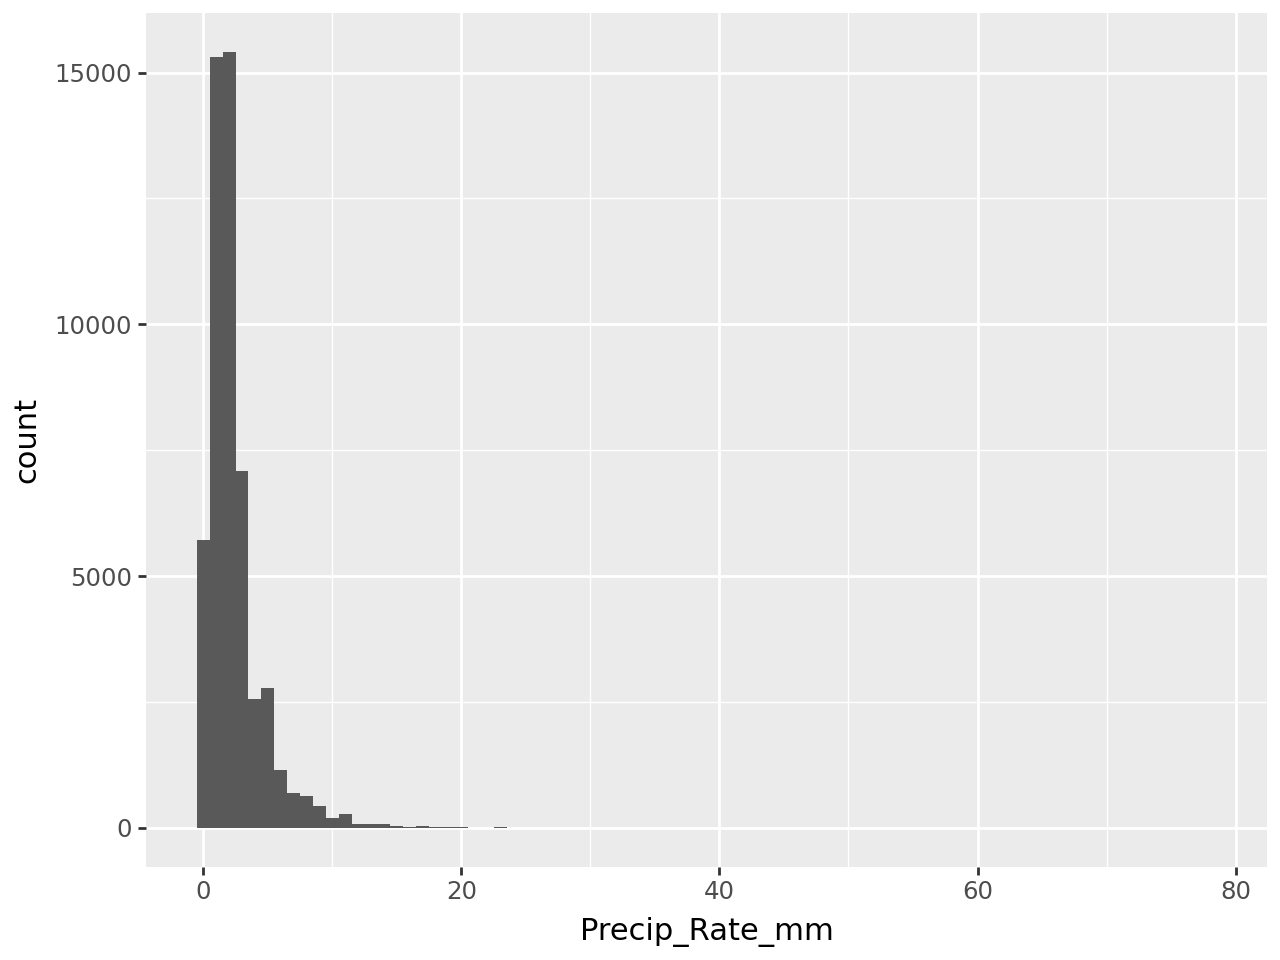

In [43]:
(
    weather
    .loc[weather['Precip_Rate_mm'] != 0,:]
    >>
    p9.ggplot(p9.aes(x="Precip_Rate_mm"))
    + p9.geom_histogram(binwidth=1)
)

# Precipitation

We're interested in precipitation particularly, so let's try to understand how "accumulated precip" relates to "precip rate".

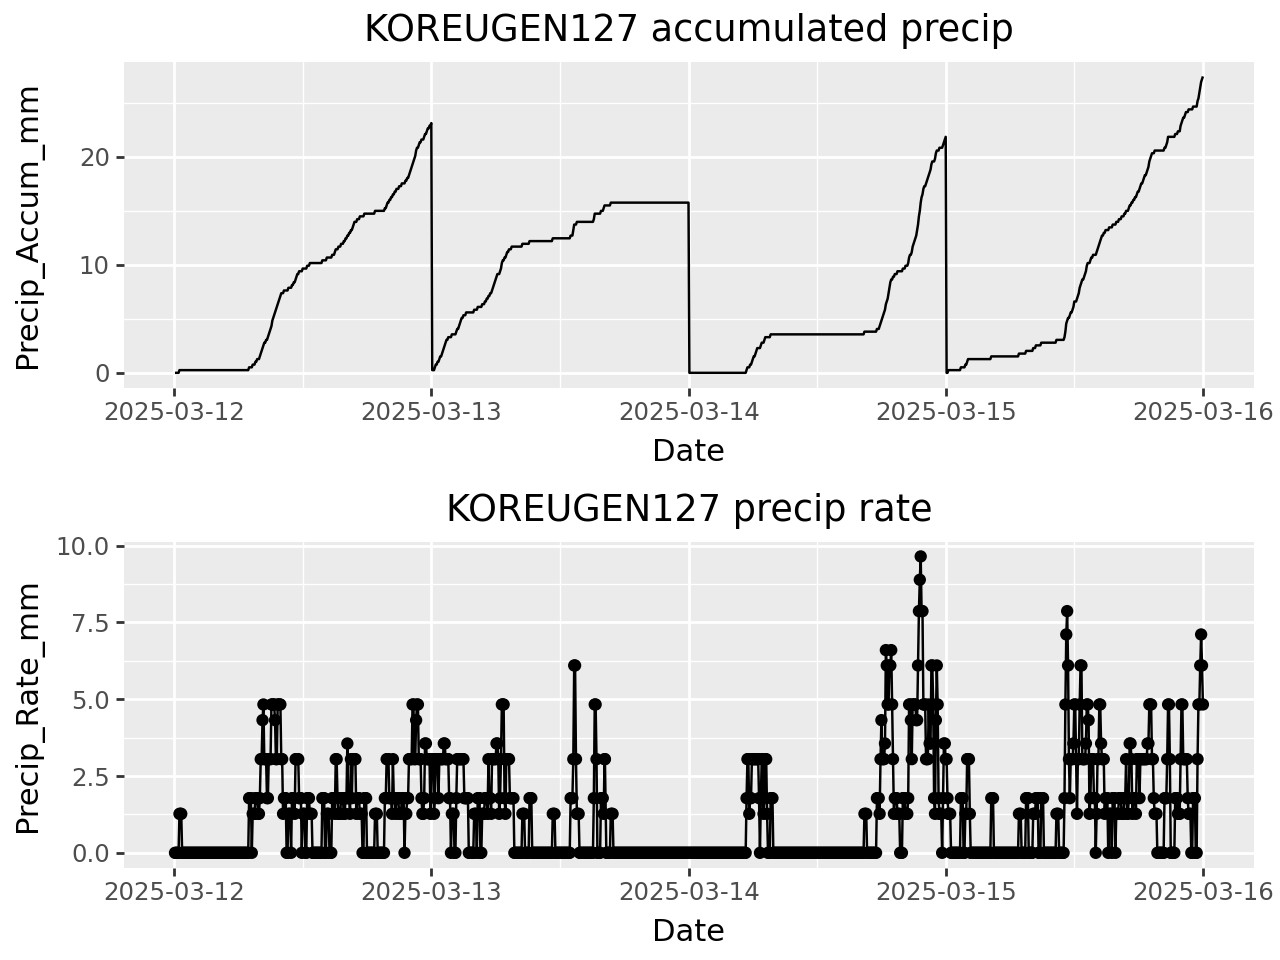

In [62]:
this_station = "KOREUGEN127"
this_weather = weather.query(f"code == '{this_station}' and Date > '2025-03-12' and Date < '2025-03-16'")

(
    this_weather
    >> p9.ggplot(p9.aes(x="Date", y="Precip_Accum_mm"))
    + p9.geom_line()
    + p9.labs(title=this_station + " accumulated precip")
) / (
    this_weather
    >> p9.ggplot(p9.aes(x="Date", y="Precip_Rate_mm"))
    + p9.geom_line() + p9.geom_point()
    + p9.labs(title=this_station + " precip rate")
)

Interesting: "accumulated precip" rises (until something gets full?) and then drops to zero - maybe at midnight?

It looks like - at least roughly - "accumulated precip" only goes up when "precip rate" is nonzero.
This would make sense if "precipitation rate" is "how much rain accumulated since the last measurement" divided by "how much time since the last measurement".
Let's see if that holds.

In [57]:
pd.crosstab(
    this_weather['Precip_Accum_mm'].diff() > 0,
    this_weather['Precip_Rate_mm'] > 0,
)

Precip_Rate_mm,False,True
Precip_Accum_mm,,
False,479,163
True,0,221


Short answer here is that it *doesn't* hold. So, "rate" is estimated in some other way.
Probably if we want to get "how much rain fell between time X and time Y" then
we need to subtract "rain accumulated up to time X" from "rain accumulated up to time Y",
while dealing somehow with the "resets" (drops to zero).

# Other variables

Let's do histograms of the other variables.
I'll do this programatically, to demonstrate how it can be done:

In [114]:
weather.columns

Index(['Date', 'Time', 'Temperature_C', 'Dew_Point_C', 'Humidity_%', 'Wind',
       'Speed_kmh', 'Gust_kmh', 'Pressure_hPa', 'Precip_Rate_mm',
       'Precip_Accum_mm', 'UV', 'Solar_w/m2', 'code'],
      dtype='object')

/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 49131 rows containing non-finite values.
/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 146043 rows containing non-finite values.
/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 49131 rows containing non-finite values.
/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 48560 rows containing non-finite values.
/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 49131 rows containing non-finite values.
/home/peter/micromamba/envs/ds435/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 48560 rows containing non-finite values.
/home/peter/micromamb

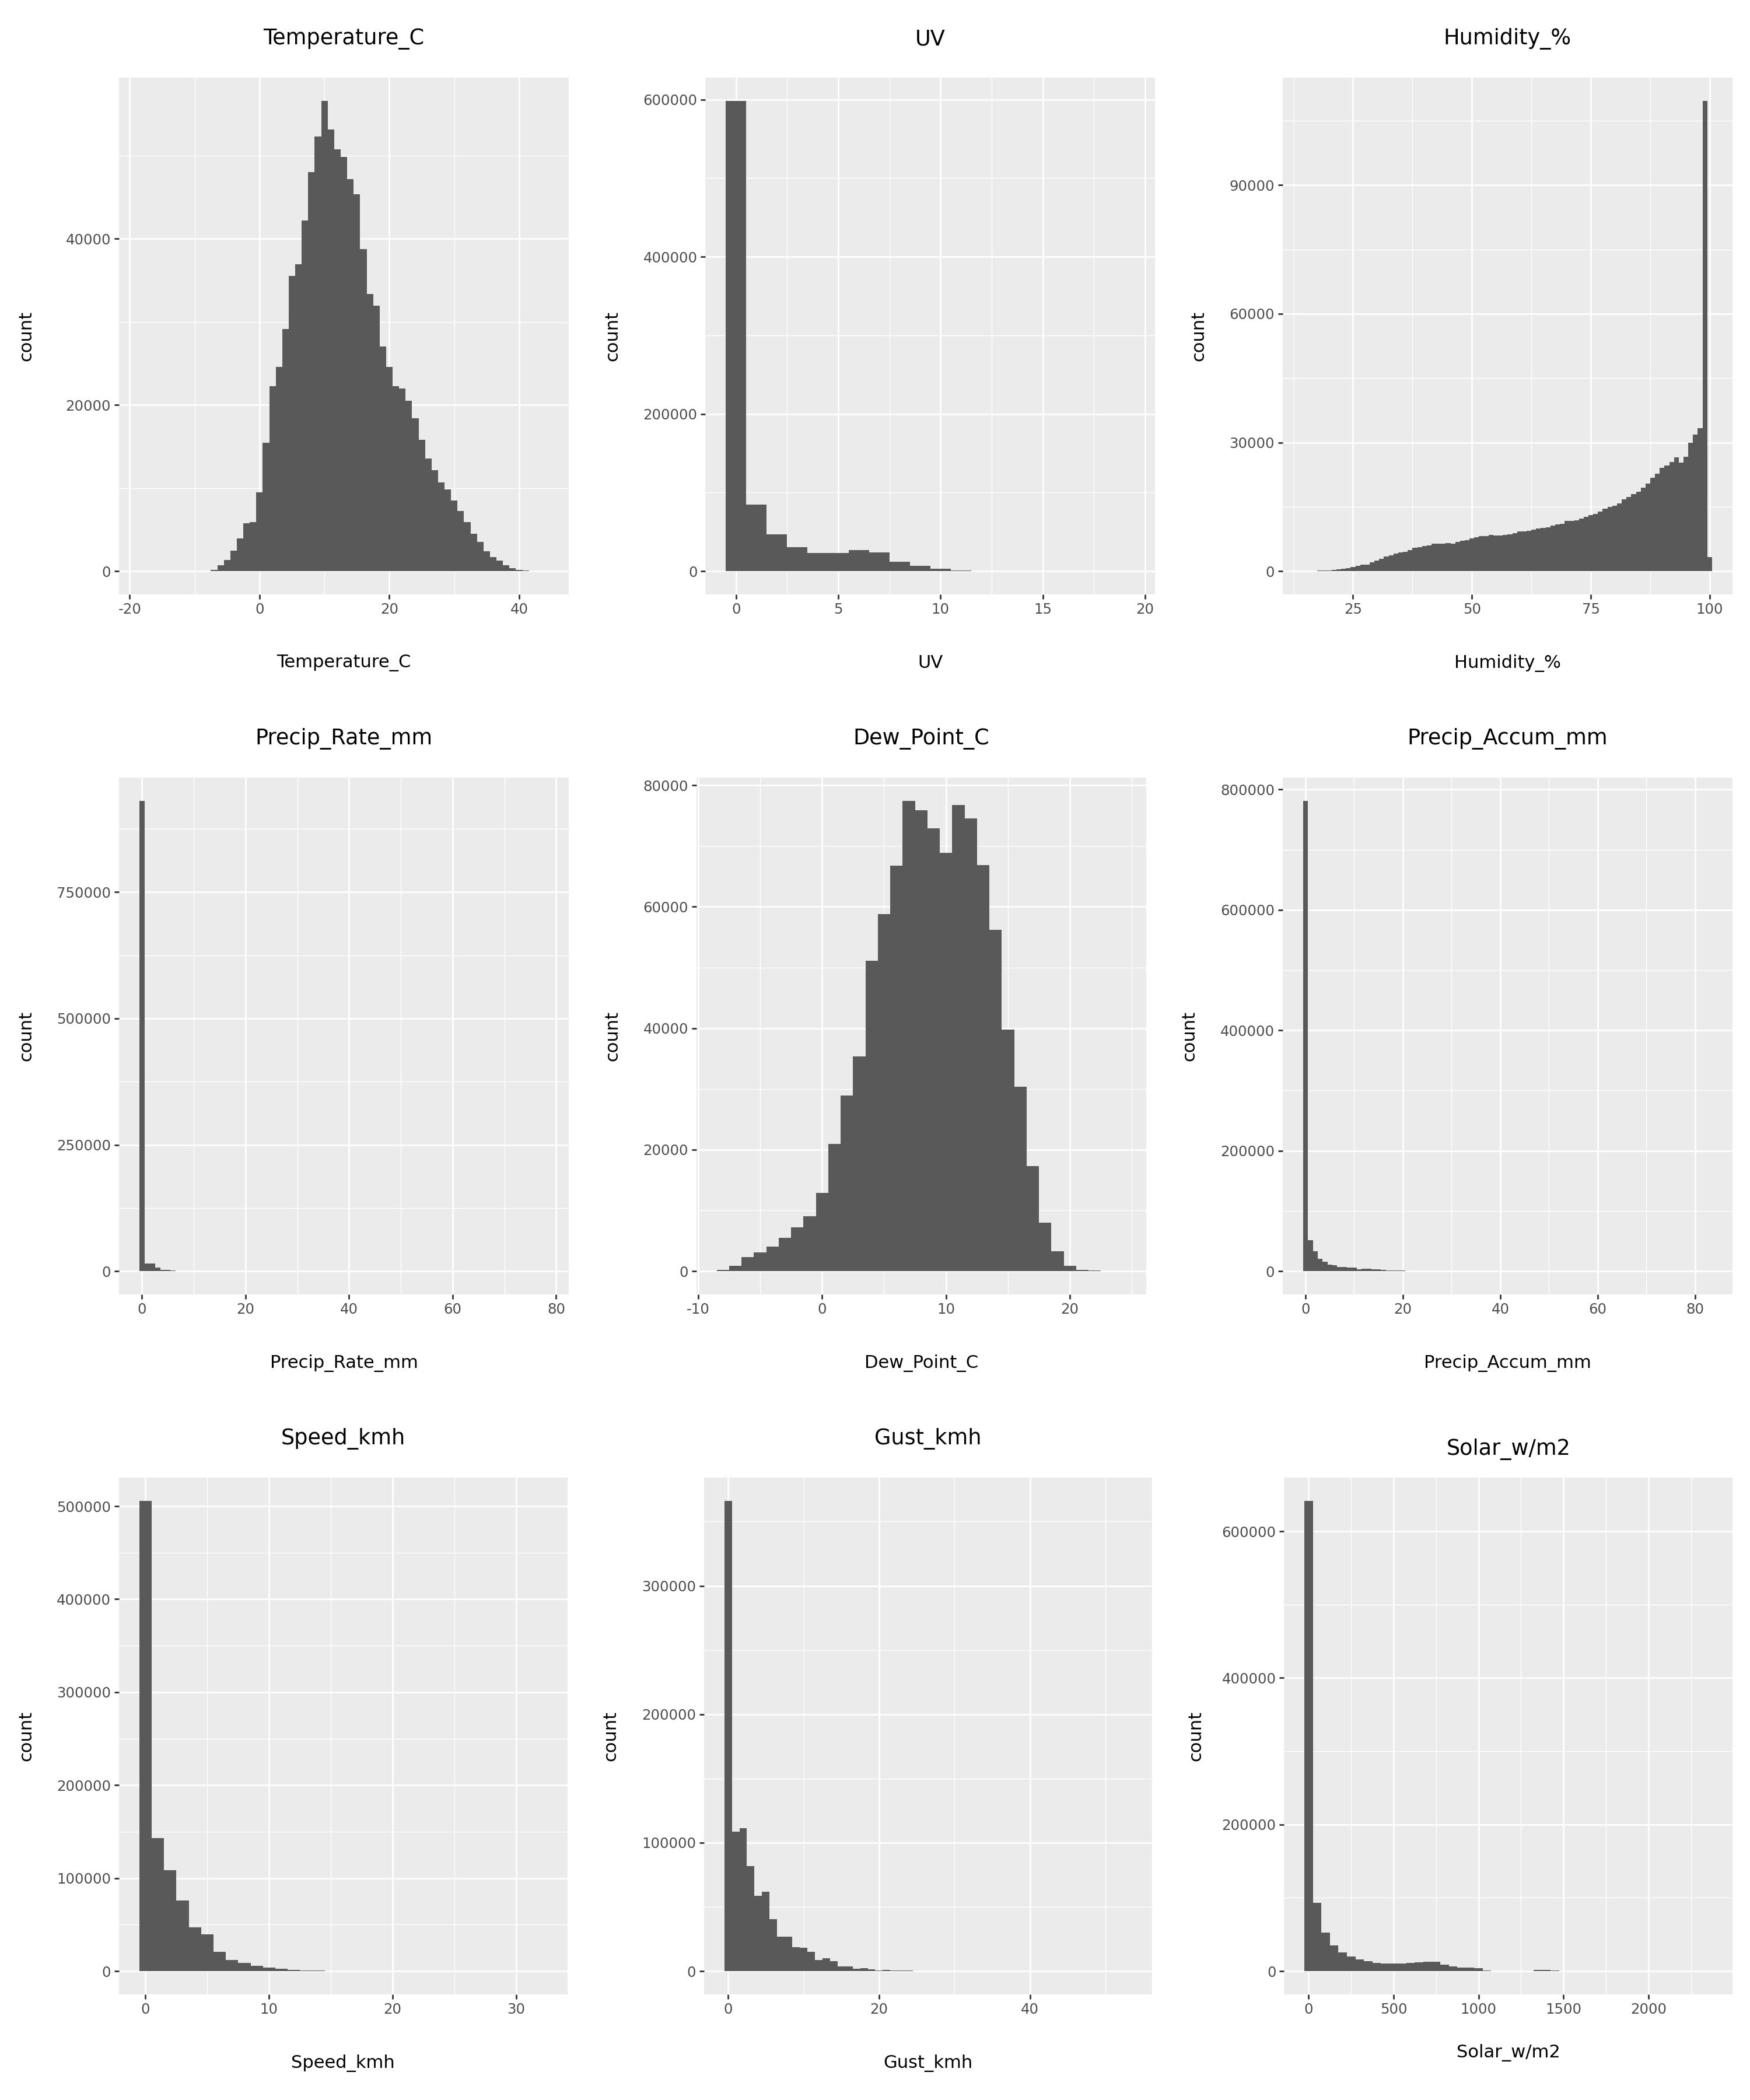

In [116]:
import collections
bw = collections.defaultdict(lambda: 1, {'Solar_w/m2': 50})
pp = [
    p9.ggplot(weather, p9.aes(x=n)) + p9.geom_histogram(binwidth=bw[n]) + p9.labs(title=n)
    for n in set(weather.columns).difference(['Wind', 'code', 'Date', 'Time'])
]
pl = [ (pp[3*k] | pp[3*k+1] | pp[3*k+2]) for k in range(int(len(pp)/3)) ]
(pl[0] / pl[1] / pl[2]) + p9.theme(figure_size=(15,18))

Let's check the recording times:

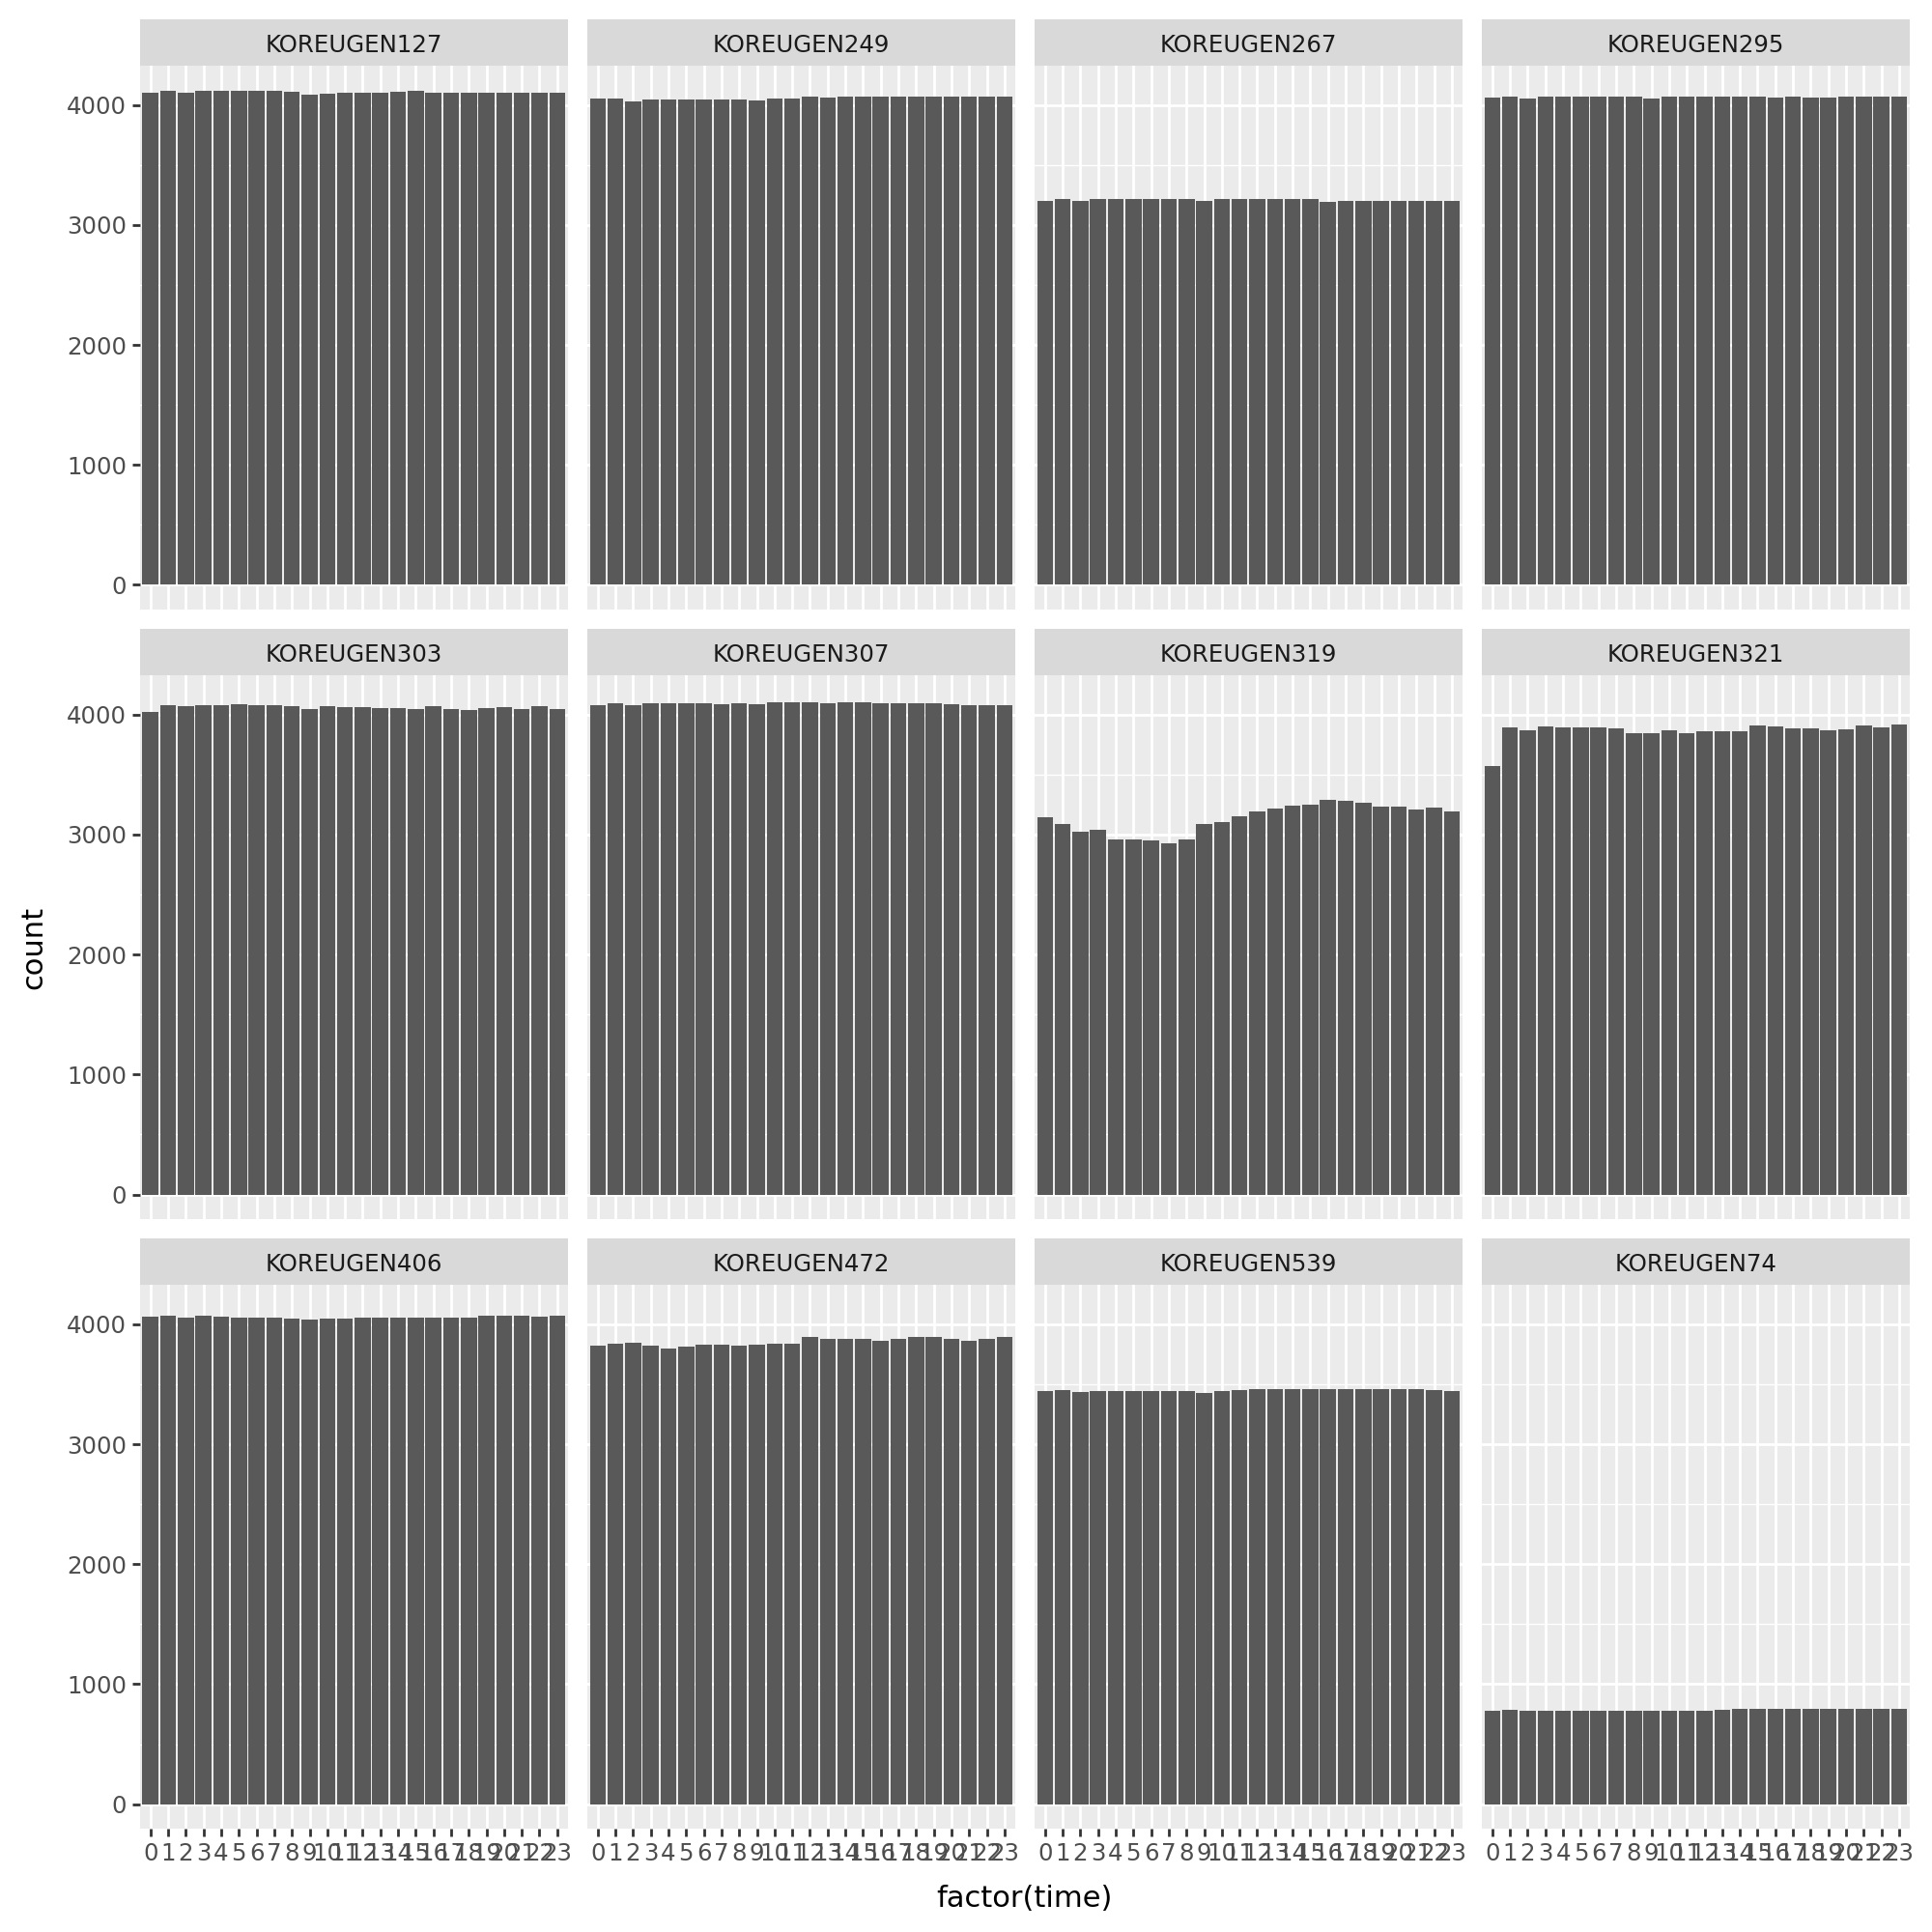

In [126]:
(
    weather
    .assign(time=lambda df: df['Date'].dt.hour)
    >> p9.ggplot(p9.aes(x="factor(time)")) + p9.geom_bar() + p9.facet_wrap("code") + p9.theme(figure_size=(10,10))
)

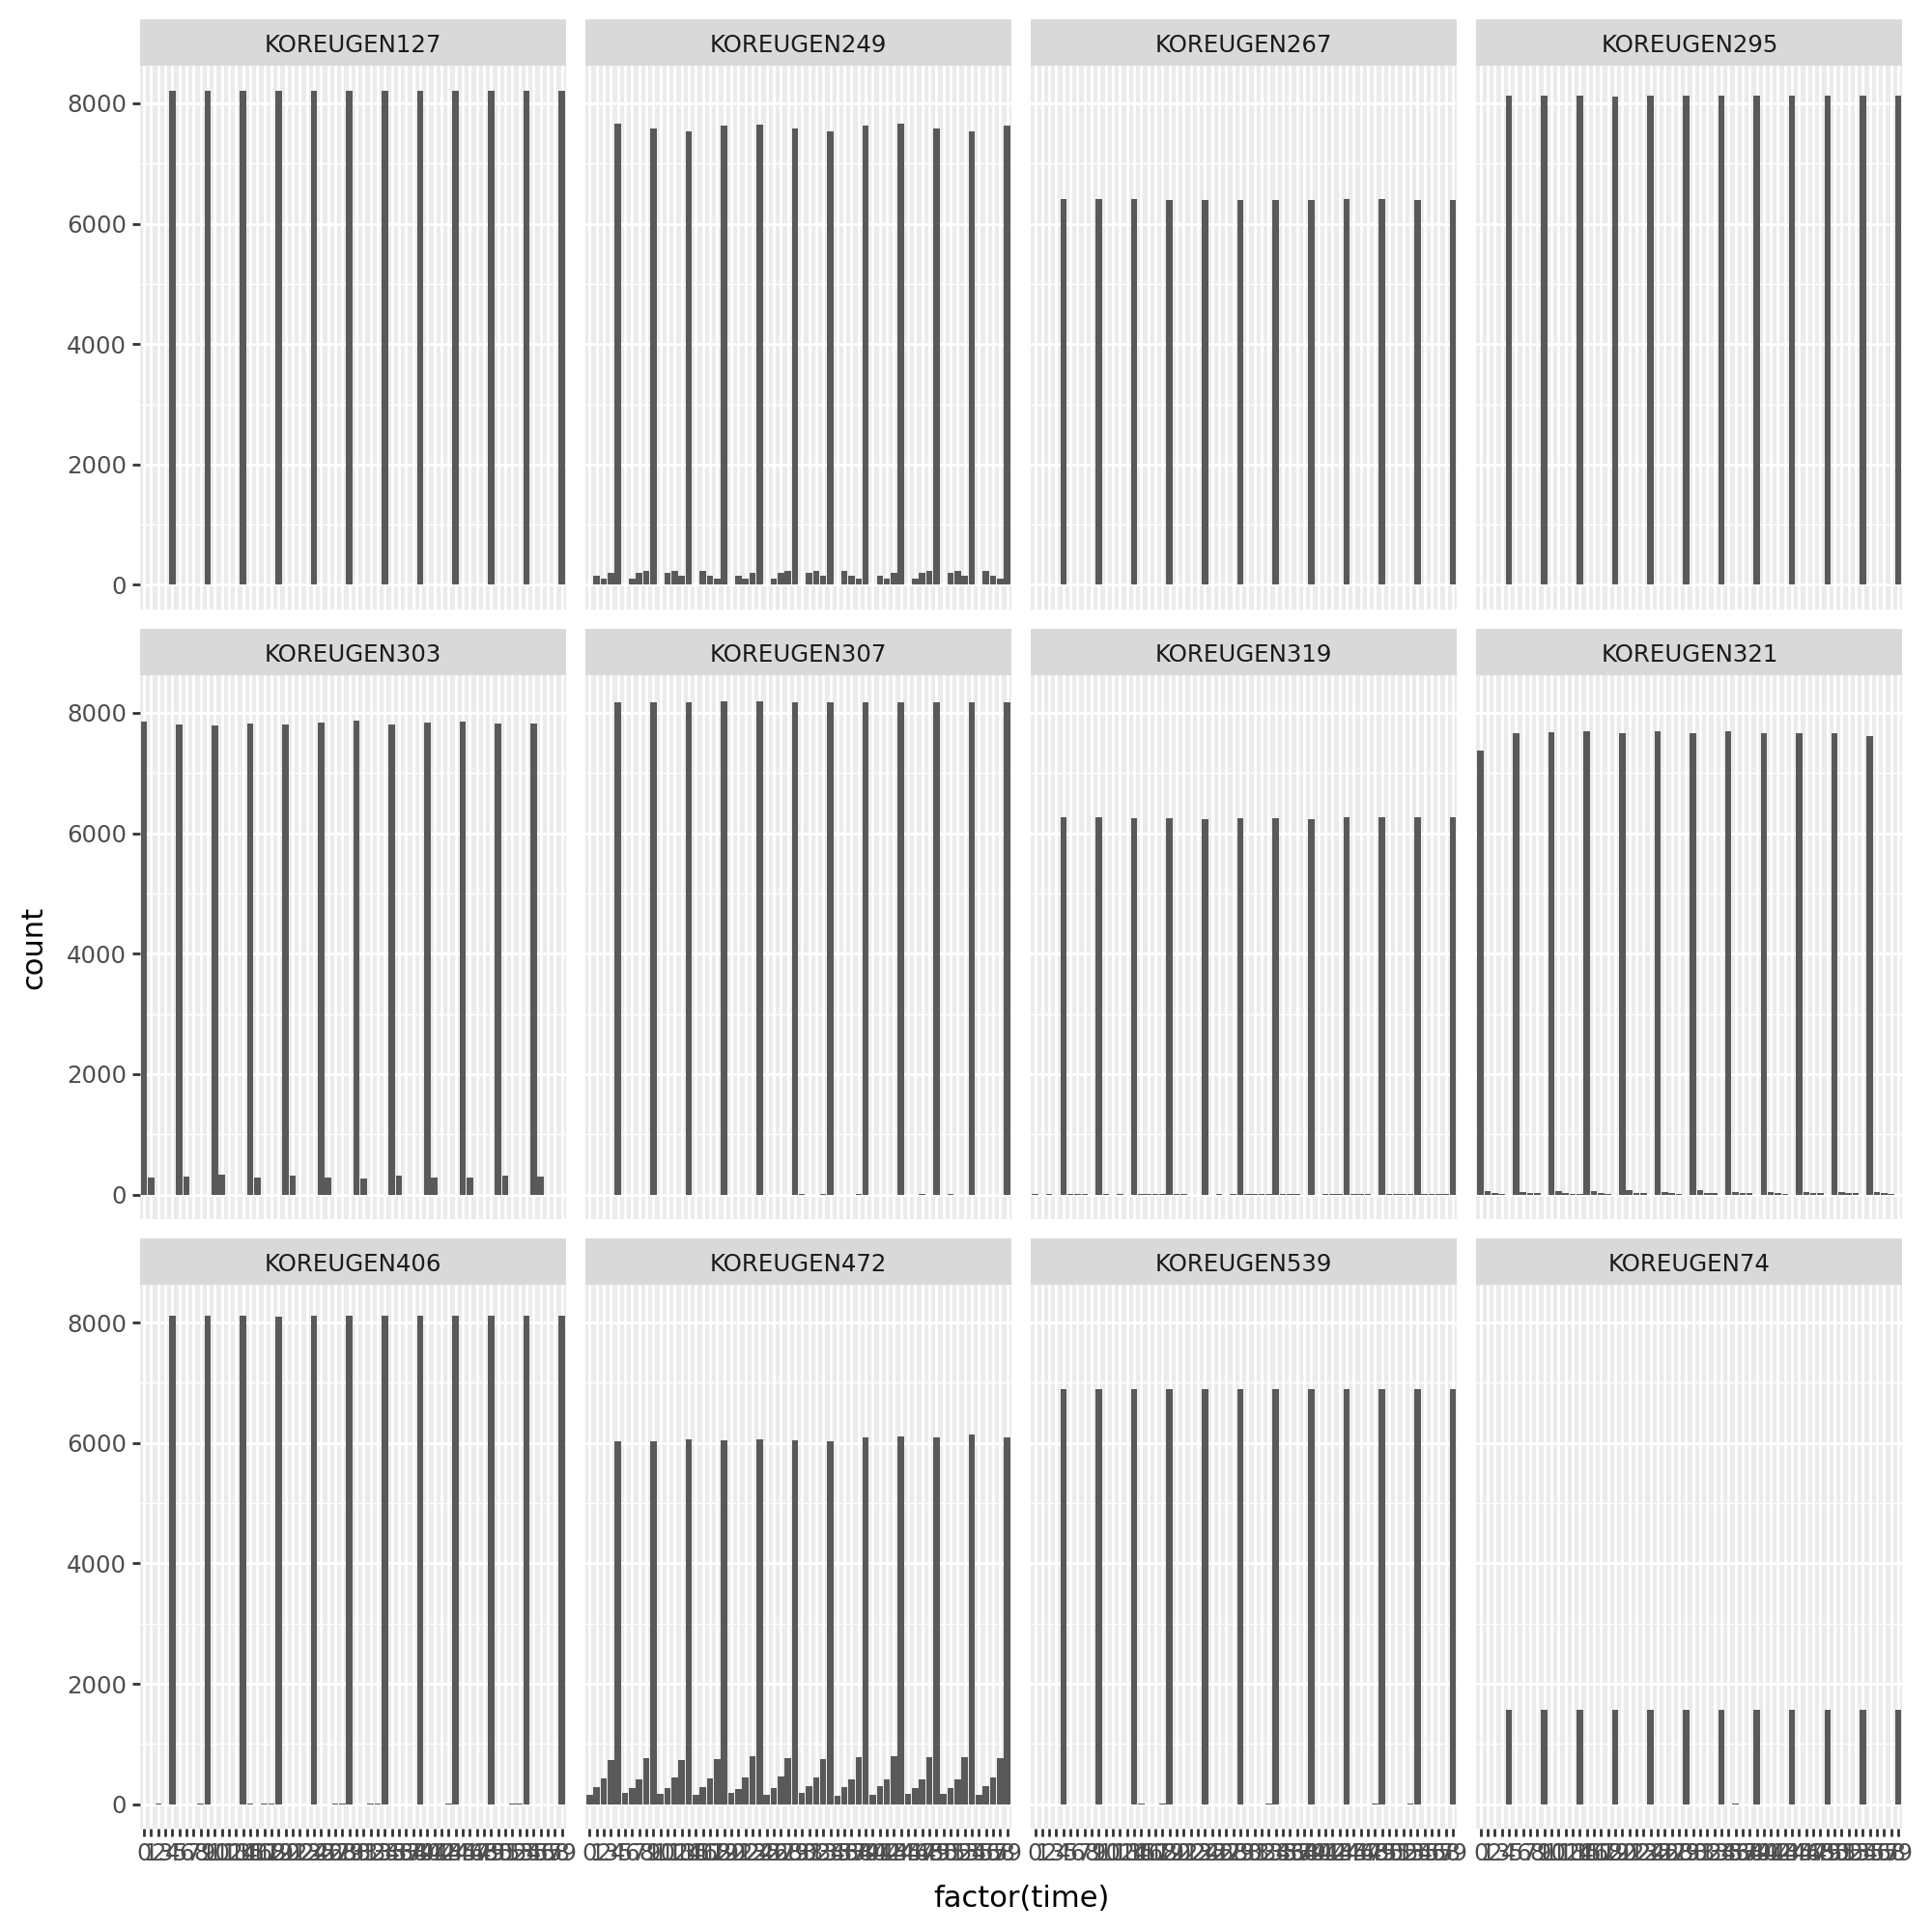

In [127]:
(
    weather
    .assign(time=lambda df: df['Date'].dt.minute)
    >> p9.ggplot(p9.aes(x="factor(time)")) + p9.geom_bar() + p9.facet_wrap("code") + p9.theme(figure_size=(10,10))
)

# Temperature and pressure

Let's just look at some more things:
for instance, how's temperature and pressure change together?
To see this reasonably we'll zoom in on a few stations, in just one month.

**Note:** it's important to use `geom_path` here, instead of `geom_line`,
since the latter sorts points by position on the x-axis.

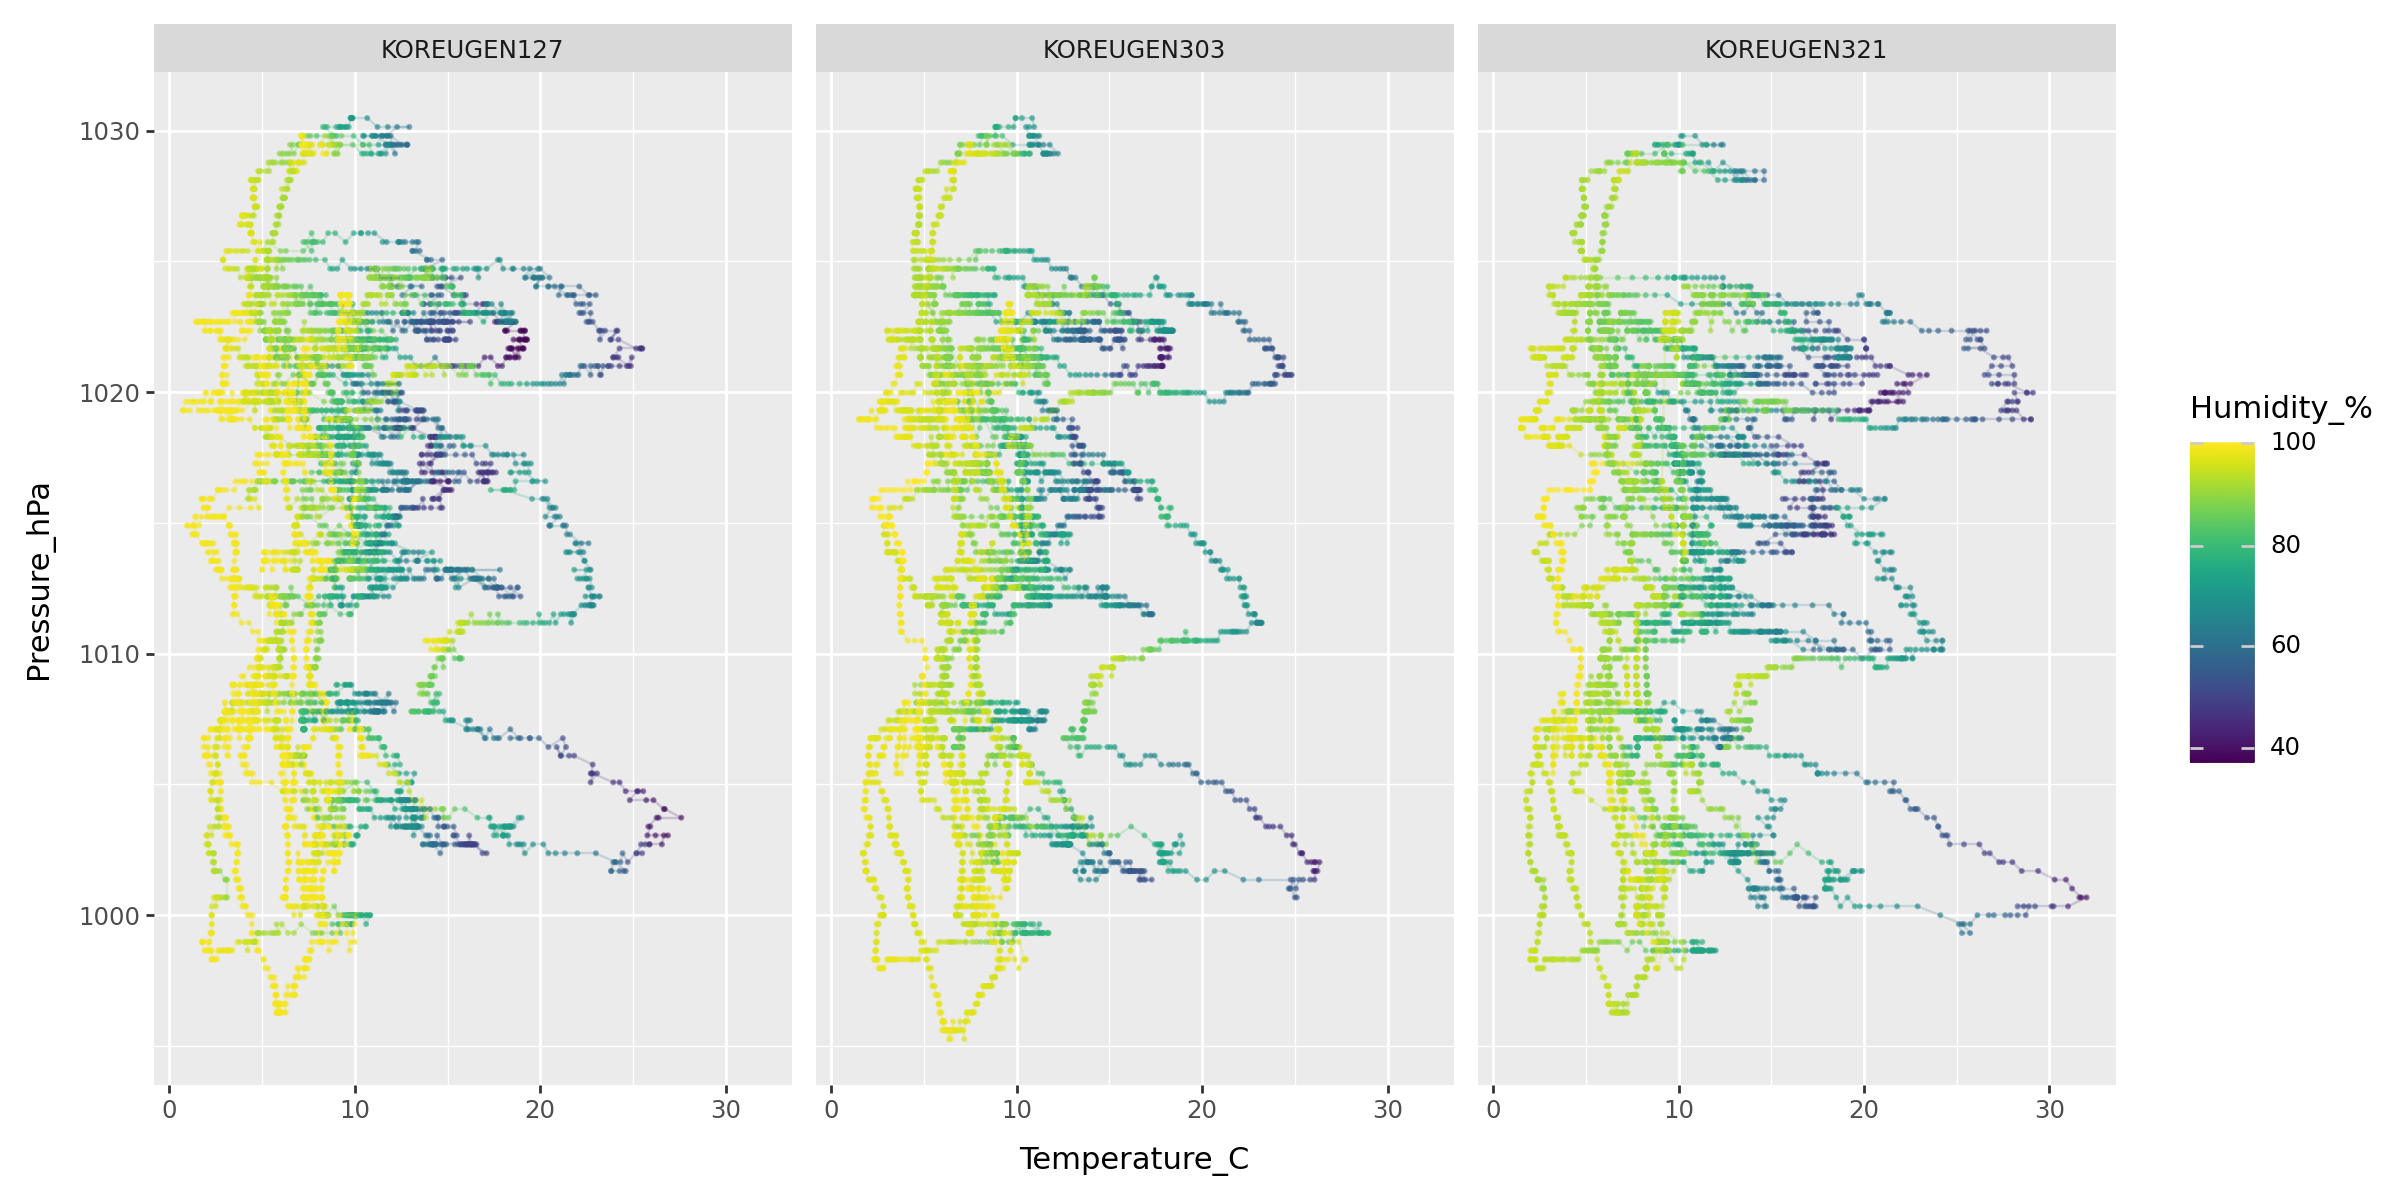

In [103]:
(
    weather
    .loc[weather['code'].isin(["KOREUGEN321", "KOREUGEN303", "KOREUGEN127"]) & (weather['Date'].dt.month == 3),:]
    >>
    p9.ggplot(p9.aes(x="Temperature_C", y="Pressure_hPa", color="Humidity_%"))
    + p9.geom_point(alpha=0.5, size=1, shape=".")
    + p9.geom_path(alpha=0.2)
    + p9.facet_wrap("code")
    + p9.theme(figure_size=(12,6))
)

Well, that's neat.